In [329]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

In [338]:
class Segment:

    def __init__(self, start: float, end: float) -> None:
        if start >= end: raise Exception(f"those segments must be valid and contain more than one value, found [{start}, {end}]")
        self.set_start(start)
        self.set_end(end)

    def __contains__(self, item: float|Segment) -> bool:
        if isinstance(item, float) or isinstance(item, int):
            return self.get_start() <= item <= self.get_end()
        elif isinstance(item, Segment):
            return self.get_start() <= item.get_start() and item.get_end() <= self.get_end()

    def __repr__(self) -> str:
        return f"S[{self.get_start()}, {self.get_end()}]S"

    def __eq__(self, other: Segment):
        return self.get_start() == other.get_start() and self.get_end() == other.get_end()

    def __hash__(self):
        return hash(tuple(sorted(self.__dict__.items())))

    def copy(self) -> Segment:
        return Segment(self.get_start(), self.get_end())

    def get_start(self) -> float:
        return self.start

    def get_end(self) -> float:
        return self.end

    def set_start(self, new_start: float) -> None:
        self.start = new_start

    def set_end(self, new_end: float) -> None:
        self.end = new_end

    def as_tuple(self) -> tuple[float, float]:
        return (self.get_start(), self.get_end())

In [ ]:
class HullByParts:

    def __init__(self, 
                 reference_function: callable[float, float],
                 subfunctions_to_segments: dict[tuple[float, float], list[Segment]] = {},
                 curves_to_add: list[tuple[float, float]] = [],
                 function_range: Segment = None, 
                 reference_primitive: callable[float, callable[float, float]] = None
                 ) -> None:
        self.set_reference_function(reference_function)
        self.set_subfunctionSegments(subfunctions_to_segments)
        self.set_range(function_range)
        self.set_primitive(reference_primitive)

        self.verify_validity()

        self.sanitize_subfunctions()
        self.sanitize_segments()
        if function_range is None: self.set_range(self.infer_range())

        for params in curves_to_add:
            self.add_subfunction(params)


    ###################### show #####################

    def __repr__(self):
        res = "defined by :\n"
        for obj in self.get_subfunctionSegments().items():
            res += str(obj) + "\n"
        res += "on : " + str(self.get_range())

        return res

    def print_dict(self):
        for obj in self.get_subfunctionSegments().items(): print(obj)


    ############### Callers #########################

    def __call__(self, x: float|list[float]|np.ndarray) -> float|np.ndarray:
        if isinstance(x, float):return self.call_float(x)
        else:                   return self.call_iter(x) 

    def call_iter(self, l) -> np.ndarray:
        return np.array(list(map(lambda x: self.call_float(x), l)))
    
    def call_float(self, x: float) -> float:
        for (slope, x_intercept), segments in self.get_subfunctionSegments().items():
            for segment in segments:
                if x in segment:
                    return self.f(slope * (x - x_intercept))
        raise Exception(f"could not find {x} in the definition set of the function")


    ################ copy ################

    def copy_dict(self) -> dict[tuple[float, float], list[Segment]]: 
        new_dict = {}

        for params, segments in self.get_subfunctionSegments().items():
            new_dict[params] = [segment.copy() for segment in segments]

        return new_dict

    def copy(self) -> HullByParts:
        return HullByParts(reference_function=self.get_reference_function(), subfunctions_to_segments=self.copy_dict(), curves_to_add=[], function_range=self.get_range().copy(), reference_primitive=self.get_primitive())


    ################# getters, setters, basic adders #####################

    def get_reference_function(self) -> callable[float, float]:
        return self.f
    
    def set_reference_function(self, f: callable[float, float]) -> None:
        self.f = f

    def get_primitive(self) -> callable[float, callable[float, float]]:
        return self.primitive

    def set_primitive(self, f: callable[float, callable[float, float]]) -> None:
        self.primitive = f

    def get_range(self) -> Segment:
        return self.f_range

    def set_range(self, segment: Segment) -> None:
        self.f_range = segment

    def get_subfunctionSegments(self) -> dict[tuple[float, float], list[Segment]]:
        return self.subfunctionSegments
    
    def set_subfunctionSegments(self, dic: dict[tuple[float, float], list[Segment]]) -> None:
        self.subfunctionSegments = dic
    
    def get_all_segments(self) -> list[Segment]:
        return [inter for list_inter in self.get_subfunctionSegments().values() for inter in list_inter]
    
    def add_subfunctionSegment(self, params: tuple[float, float], segment: Segment) -> None:
        if params in self.get_subfunctionSegments():
            self.subfunctionSegments[params].append(segment)
        else:
            self.subfunctionSegments[params] = [segment]

    def add_subfunctionSegments(self, params: tuple[float, float], segment_list: list[Segment]) -> None:
            if params in self.get_subfunctionSegments():
                self.subfunctionSegments[params] += segment_list
            else:
                self.subfunctionSegments[params] = segment_list


    #################### sanitizers ########################

    def sanitize_subfunctions(self) -> None:
        for (s, x), segments in self.get_subfunctionSegments().items():
            if s < 0:
                del self.subfunctionSegments[(s, x)]
                self.subfunctionSegments[(-s, -x)] = segments

    def sanitize_segments(self) -> None:
        for segments in self.get_subfunctionSegments().values():
            segments.sort(key=lambda i: i.get_start())

            i = 0
            while i < len(segments) - 1:
                if segments[i].get_end() == segments[i+1].get_start():
                    segments[i].set_end(segments[i+1].get_end())
                    del segments[i+1]
                else:
                    i += 1

    def infer_range(self) -> Segment:
            all_segments = self.get_all_segments()
            return Segment(min(all_segments, key=lambda i: i.get_start()).get_start(), max(all_segments, key=lambda i: i.get_end()).get_end())

    @staticmethod
    def sanitize_parameters(params: tuple[float, float]) -> tuple[float, float]:
        s, x = params
        if s < 0:   s, x = -s, -x
        elif s == 0: raise Exception("slope must not be 0, subfunctions must be bijective on R")

        return s, x

    ###################### verifiers #############################

    def verify_slope(self) -> None:
        for (s, _) in self.get_subfunctionSegments().keys():
            if s == 0:
                raise Exception("slope must not be 0, subfunctions must be bijective on R")

    def verify_defined_on_all_segment(self) -> None:
        sorted_segments = sorted(self.get_all_segments(), key = lambda segment: segment.get_start())

        if sorted_segments != [] and self.get_range() is not None and (self.get_range().get_start() != sorted_segments[0].get_start() or self.get_range().get_end() != sorted_segments[-1].get_end()):
            raise Exception("the function must be defined on its entire range, ends do not match")

        for segment1, segment2 in pairwise(sorted_segments):
            if segment1.get_end() != segment2.get_start(): raise Exception("the function should be defined on the total range it takes values in")

    def verify_validity(self) -> None:
        print(self)
        self.verify_slope()
        self.verify_defined_on_all_segment()


    ##################### complex adders #################
    
    @staticmethod
    def add_intersection(useful_intersections: dict[tuple[float, float], dict[Segment, list[tuple[float, bool]]]], 
                         param: tuple[float, float], 
                         segment: Segment, 
                         intersect: tuple[float, bool]
                         ) -> None:
        if param not in useful_intersections:
            useful_intersections[param] = {segment: [intersect]}
        elif segment not in useful_intersections[param]:
            useful_intersections[param][segment] = [intersect]
        else:
            useful_intersections[param][segment].append(intersect)

    @staticmethod
    def all_intersections(useful_intersections: dict[tuple[float, float], dict[Segment, list[tuple[float, bool]]]]) -> list[float]:
        res = []
        for segments in useful_intersections.values():
            for list_intersections in segments.values():
                for value, _ in list_intersections:
                    res.append(value)
        return sorted(res)

    @staticmethod
    def intersection_points(g: tuple[float, float], h: tuple[float, float]) -> list[float]:
        g_slope, g_x_inter = g
        h_slope, h_x_inter = h

        opposite_intersect = (g_x_inter*g_slope + h_x_inter*h_slope)/(g_slope + h_slope)
        if g_slope - h_slope == 0:  return [opposite_intersect]

        concurrent_intersect = (g_x_inter*g_slope - h_x_inter*h_slope)/(g_slope - h_slope)
        return [opposite_intersect, concurrent_intersect]

    @staticmethod
    def skip_intersection_condition_left(intersection: float, 
                                         segment: Segment, 
                                         is_same_side: bool, 
                                         previous_curb_root: float, 
                                         new_curb_root: float
                                         ) -> bool:
        return intersection == segment.get_start() or (intersection == segment.get_end() and (is_same_side or previous_curb_root > new_curb_root))

    @staticmethod
    def skip_intersection_condition_right(intersection: float, 
                                         segment: Segment, 
                                         is_same_side: bool, 
                                         previous_curb_root: float, 
                                         new_curb_root: float
                                         ) -> bool:
        return intersection == segment.get_end() or (intersection == segment.get_start() and (is_same_side or previous_curb_root < new_curb_root))

    def process_intersections(self, 
                              parameters: tuple[float, float], 
                              curbs_params: list[tuple[float, float]], 
                              useful_intersections: dict[tuple[float, float], dict[Segment, list[tuple[float, bool]]]], 
                              considered_curbs: list[tuple[float, float]], 
                              skip_intersection_condition: callable[float, Segment, bool, float, float, bool]
                              ) -> None:
            a, b = parameters
    
            current_min_slope = a
            activate_skip = False
            for params in curbs_params:
                c, d = params
                if c >= current_min_slope and activate_skip: continue
                
                considered_curbs.append(params)
                if c <= current_min_slope: 
                    current_min_slope = c
                    if not activate_skip: activate_skip = True
    
                segments = self.get_subfunctionSegments()[params]
                intersections = HullByParts.intersection_points(parameters, params)
                
                for i, intersection in enumerate(intersections):
                    for segment in segments:
                        if intersection not in segment: continue

                        if skip_intersection_condition(intersection, segment, i == 0, d, b):
                            continue
                        else:
                            HullByParts.add_intersection(useful_intersections, params, segment, (intersection, i == 0))

    def find_useful_intersections(self, parameters: tuple[float, float]) -> tuple[list, list, list]:
        _, b = parameters
        get_keys = self.get_subfunctionSegments().keys()

        curbs_sorting_key = lambda k: k[1]
        left_curbs_params = sorted([k for k in get_keys if k[1] < b], key=curbs_sorting_key, reverse=True)
        right_curbs_params = sorted([k for k in get_keys if k[1] > b], key=curbs_sorting_key)
        
        useful_intersections = {}
        considered_curbs = []

        self.process_intersections(parameters, left_curbs_params, useful_intersections, considered_curbs, lambda *x: HullByParts.skip_intersection_condition_left(*x))
        self.process_intersections(parameters, right_curbs_params, useful_intersections, considered_curbs, lambda *x: HullByParts.skip_intersection_condition_right(*x))           
                        
        return useful_intersections, considered_curbs

    def process_previous_curbs(self, 
                               parameters: tuple[float, float], 
                               usefull_intersections: dict[tuple[float, float], dict[Segment, list[tuple[float, bool]]]]
                               ) -> None:
        a, b = parameters
        for params in usefull_intersections:
            for segment in usefull_intersections[params]:
                intersects = usefull_intersections[params][segment]
                if len(intersects) == 1:
                    intersection, side = intersects[0]
                    if side == (intersection < b):  segment.set_end(intersection)#TODO
                    else:                           segment.set_start(intersection)

                else: # = 2
                    c, d = params
                    (i_opposite, _), (i_sameside, _) = intersects
                    if c < a:
                        if d < b:
                            if segment.get_end() != i_sameside:
                                self.add_subfunctionSegment(params, Segment(i_sameside, segment.get_end()))
                            segment.set_end(i_opposite)
                        else:
                            if segment.get_start() != i_sameside:
                                self.add_subfunctionSegment(params, Segment(segment.get_start(), i_sameside))
                            segment.set_start(i_opposite)

                    else:
                        if d < b:
                            segment.set_start(i_sameside)
                            segment.set_end(i_opposite)
                        else:
                            segment.set_start(i_opposite)
                            segment.set_end(i_sameside)

    def process_new_segments(self, 
                             parameters: tuple[float, float], 
                             all_intersections: list[float]
                             ) -> list[tuple[float, float]]:
        _, b = parameters
        segments = []

        if len([value for value in all_intersections if value < b])%2 == 0:
            value_to_remember = self.get_range().get_start()
        else:
            value_to_remember = None

        for value in all_intersections:
            if value_to_remember is not None:
                segments.append(Segment(value_to_remember, value))
                value_to_remember = None
            else:
                value_to_remember = value
        if value_to_remember is not None:
            segments.append(Segment(value_to_remember, self.get_range().get_end()))

        self.add_subfunctionSegments(parameters, segments)

        return list(map(lambda segment: segment.as_tuple(), segments))
    
    def delete_superfluous_segments(self, 
                                    curbs: list[tuple[float, float]], 
                                    new_segments: list[tuple[float, float]]
                                    ) -> None:
        segments_to_delete = set()
        for curb in curbs:
            for segment in self.get_subfunctionSegments()[curb]:
                for start, end in new_segments:
                    if start <= segment.get_start() < end or start < segment.get_end() <= end: segments_to_delete.add((curb, segment))

        for params, segment in segments_to_delete:
            self.get_subfunctionSegments()[params].remove(segment)
    
    def add_subfunction(self, parameters: tuple[float, float]) -> None:
        a, b = parameters = HullByParts.sanitize_parameters(parameters)
        
        for c, d in self.get_subfunctionSegments():
            if b == d:
                if a < c:
                    del self.get_subfunctionSegments()[(c, d)]
                    break
                else:
                    print(parameters)
                    raise Exception("Not implemented")

        useful_intersections, considered_curbs = self.find_useful_intersections((a, b))
        all_intersections = HullByParts.all_intersections(useful_intersections)
        if b == 8.015075376884422:
            print("intersections :", useful_intersections)
            print("considered :", considered_curbs)
            print("all_intersections :", all_intersections)
        self.process_previous_curbs(parameters, useful_intersections)
        if b == 8.015075376884422:
            print(self)
        new_segments = self.process_new_segments(parameters, all_intersections)
        if b == 8.015075376884422:
            print("new segments", new_segments)

        self.delete_superfluous_segments(considered_curbs, new_segments)
        if b == 8.015075376884422:
            print(self)
        self.sanitize_segments()

        self.verify_validity()


    ####################### integral calculation ###################

    def compute_integral(self, on_range: Segment) -> float:
        if self.get_primitive() is None: raise Exception("primitive function not defined")
        if not on_range in self.get_range(): 
            raise Exception(f"the range on which to calculate the integral must be contained in the function definition range, {on_range} not in {self.get_range()}")

        primitive = self.get_primitive()
        integral = 0.
        for params, segments in self.get_subfunctionSegments().items():
            a, b = params
            partial = primitive(a)
            for segment in segments:
                if segment in on_range:
                    integral += partial(segment.get_end() - b) - partial(segment.get_start() - b)
                elif on_range.get_start() in segment and not on_range.get_start() == segment.get_start():
                    integral += partial(segment.get_end() - b) - partial(on_range.get_start() - b)
                elif on_range.get_end() in segment and not on_range.get_end() == segment.get_end():
                    integral += partial(on_range.get_end() - b) - partial(segment.get_start() - b)

        return integral

    def compute_integral_by_segment(self, on_range: Segment) -> dict[tuple[float, float], dict[Segment, float]]:
        if self.get_primitive() is None: raise Exception("primitive function not defined")
        if not on_range in self.get_range(): 
            raise Exception(f"the range on which to calculate the integral must be contained in the function definition range, {on_range} not in {self.get_range()}")

        primitive = self.get_primitive()
        integral = {}
        for params, segments in self.get_subfunctionSegments().items():
            integral[params] = {}
            a, b = params
            partial = primitive(a)
            for segment in segments:
                if segment in on_range:
                    integral[params][segment] = partial(segment.get_end() - b) - partial(segment.get_start() - b)
                elif on_range.get_start() in segment and not on_range.get_start() == segment.get_start():
                    integral[params][Segment(on_range.get_start(), segment.get_end())] = partial(segment.get_end() - b) - partial(on_range.get_start() - b)
                elif on_range.get_end() in segment and not on_range.get_end() == segment.get_end():
                    integral[params][Segment(segment.get_start(), on_range.get_end())] = partial(on_range.get_end() - b) - partial(segment.get_start() - b)

        return integral


    ######################### score computation ####################

    @staticmethod
    def segment_to_integral(previous_integral_segments: dict[tuple[float, float], dict[Segment, float]]):
        ret = {}
        for seg_to_integral in previous_integral_segments.values():
            for segment, integral in seg_to_integral.items():
                ret[segment] = integral
        return ret

    def score_of_new_curb_test(self, parameters):
        previous_integral_by_segment = self.compute_integral_by_segment(self.get_range())
        segment_integrals = HullByParts.segment_to_integral(previous_integral_by_segment)

        hull = self.copy()
        hull.add_subfunction(parameters)
        segments_to_compute = []
        segments_computed = []

        for params, segments in hull.get_subfunctionSegments().items():
            if params not in previous_integral_by_segment:
                segments_to_compute += segments
                continue

            for segment in segments:
                if segment not in previous_integral_by_segment[params]:
                    segments_to_compute.append(segment)
                else:
                    segments_computed.append(segment)

        old_computed_segments = list(map(lambda seg: segment_integrals[seg], segments_computed))
        new_computed_segments = list(map(lambda seg: hull.compute_integral(seg), segments_to_compute))

        old_integral = sum(segment_integrals.values())
        new_integral = sum(old_computed_segments) + sum(new_computed_segments)

        return new_integral/old_integral
        


        

In [367]:
hull = HullByParts(lambda x: x**2,
                   subfunctions_to_segments={}, 
                   curves_to_add=[(2, 4), (2, 9), (.5, 7), (2, 8), (1, 2), (.5, 10), (.4, 7)], 
                   function_range=Segment(0, 11), 
                   reference_primitive=lambda a: (lambda x: a**2 * x**3/3.))

hull.score_of_new_curb_test((1, 0))

defined by :
on : S[0, 11]S
defined by :
((2, 4), [S[0, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[0, 6.5]S])
((2, 9), [S[6.5, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 8.6]S, S[9.666666666666666, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[0, 3.3333333333333335]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.666666666666666, 9.2]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.5]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[

0.6182126696832579

In [368]:
hull = HullByParts(lambda x: x**2,
                   subfunctions_to_segments={}, 
                   curves_to_add=[(2, 4), (2, 9), (.5, 7), (2, 8), (1, 2), (.5, 10), (.4, 7)], 
                   function_range=Segment(0, 11), 
                   reference_primitive=lambda a: (lambda x: a**2 * x**3/3.))

print(hull)

defined by :
on : S[0, 11]S
defined by :
((2, 4), [S[0, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[0, 6.5]S])
((2, 9), [S[6.5, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 8.6]S, S[9.666666666666666, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[0, 3.3333333333333335]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.666666666666666, 9.2]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.5]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[

In [369]:
hull.compute_integral(Segment(3.5, 4.5))

0.3333333333333342

In [370]:
def plot_draw(ax, x, hull, draw_value_curves = True):
    ax.set_ylim((0, 4))
    ax.set_xlim((0, 11))

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionSegments():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    ax.plot(x, hull(x), color='green', ls='-', lw=10)

def plot_draw_bis(ax, x, hull: HullByParts, draw_value_curves = True, curbs_to_add = [], y_lim = (0, 4)):
    ax.set_ylim(y_lim)
    ax.set_xlim(hull.get_range().as_tuple())

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionSegments():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    if hull.get_subfunctionSegments() != {}:
        ax.plot(x, hull(x), color='green', ls='-', lw=10)

    for curb in curbs_to_add:
        hull.add_subfunction(curb)

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionSegments():
            if (slope, x_intercept) in curbs_to_add:
                func = lambda x: hull.f(slope * (x - x_intercept))
                ax.plot(x, func(x), color = 'blue', ls = '-.', alpha = .8)
    
    ax.plot(x, hull(x), color='red', ls='-', lw=3)


In [371]:
def show_iterative_fig(reference_function, function_range, data, draw_value_curves = True, nb_points = 1000, fig_width = 50, fig_height_per_ax = 10, y_limit = (0, 4)):
  x = np.linspace(*function_range, nb_points)

  subplots = len(data)
  fig, axs = plt.subplots(subplots + 1, 1, figsize=(fig_width, subplots*fig_height_per_ax))

  hull = HullByParts(reference_function, {}, function_range=Segment(*function_range))
  for i, params in enumerate(data):
    plot_draw_bis(axs[i], x, hull, draw_value_curves, curbs_to_add=[params], y_lim=y_limit)

  plot_draw(axs[-1], x, hull)
      
  fig.show()

  return hull

defined by :
on : S[0, 11]S
defined by :
((2, 4), [S[0, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[0, 6.5]S])
((2, 9), [S[6.5, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 8.6]S, S[9.666666666666666, 11]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.0, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[0, 3.0]S, S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.6, 9.666666666666666]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.6]S, S[9.666666666666666, 11]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[0, 3.3333333333333335]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.6]S])
((2, 9), [S[8.666666666666666, 9.2]S])
((0.5, 7), [S[4.6, 7.8]S, S[8.333333333333334, 8.5]S])
((2, 8), [S[7.8, 8.333333333333334]S])
((1, 2), [S[

/tmp/ipykernel_23429/1862082538.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


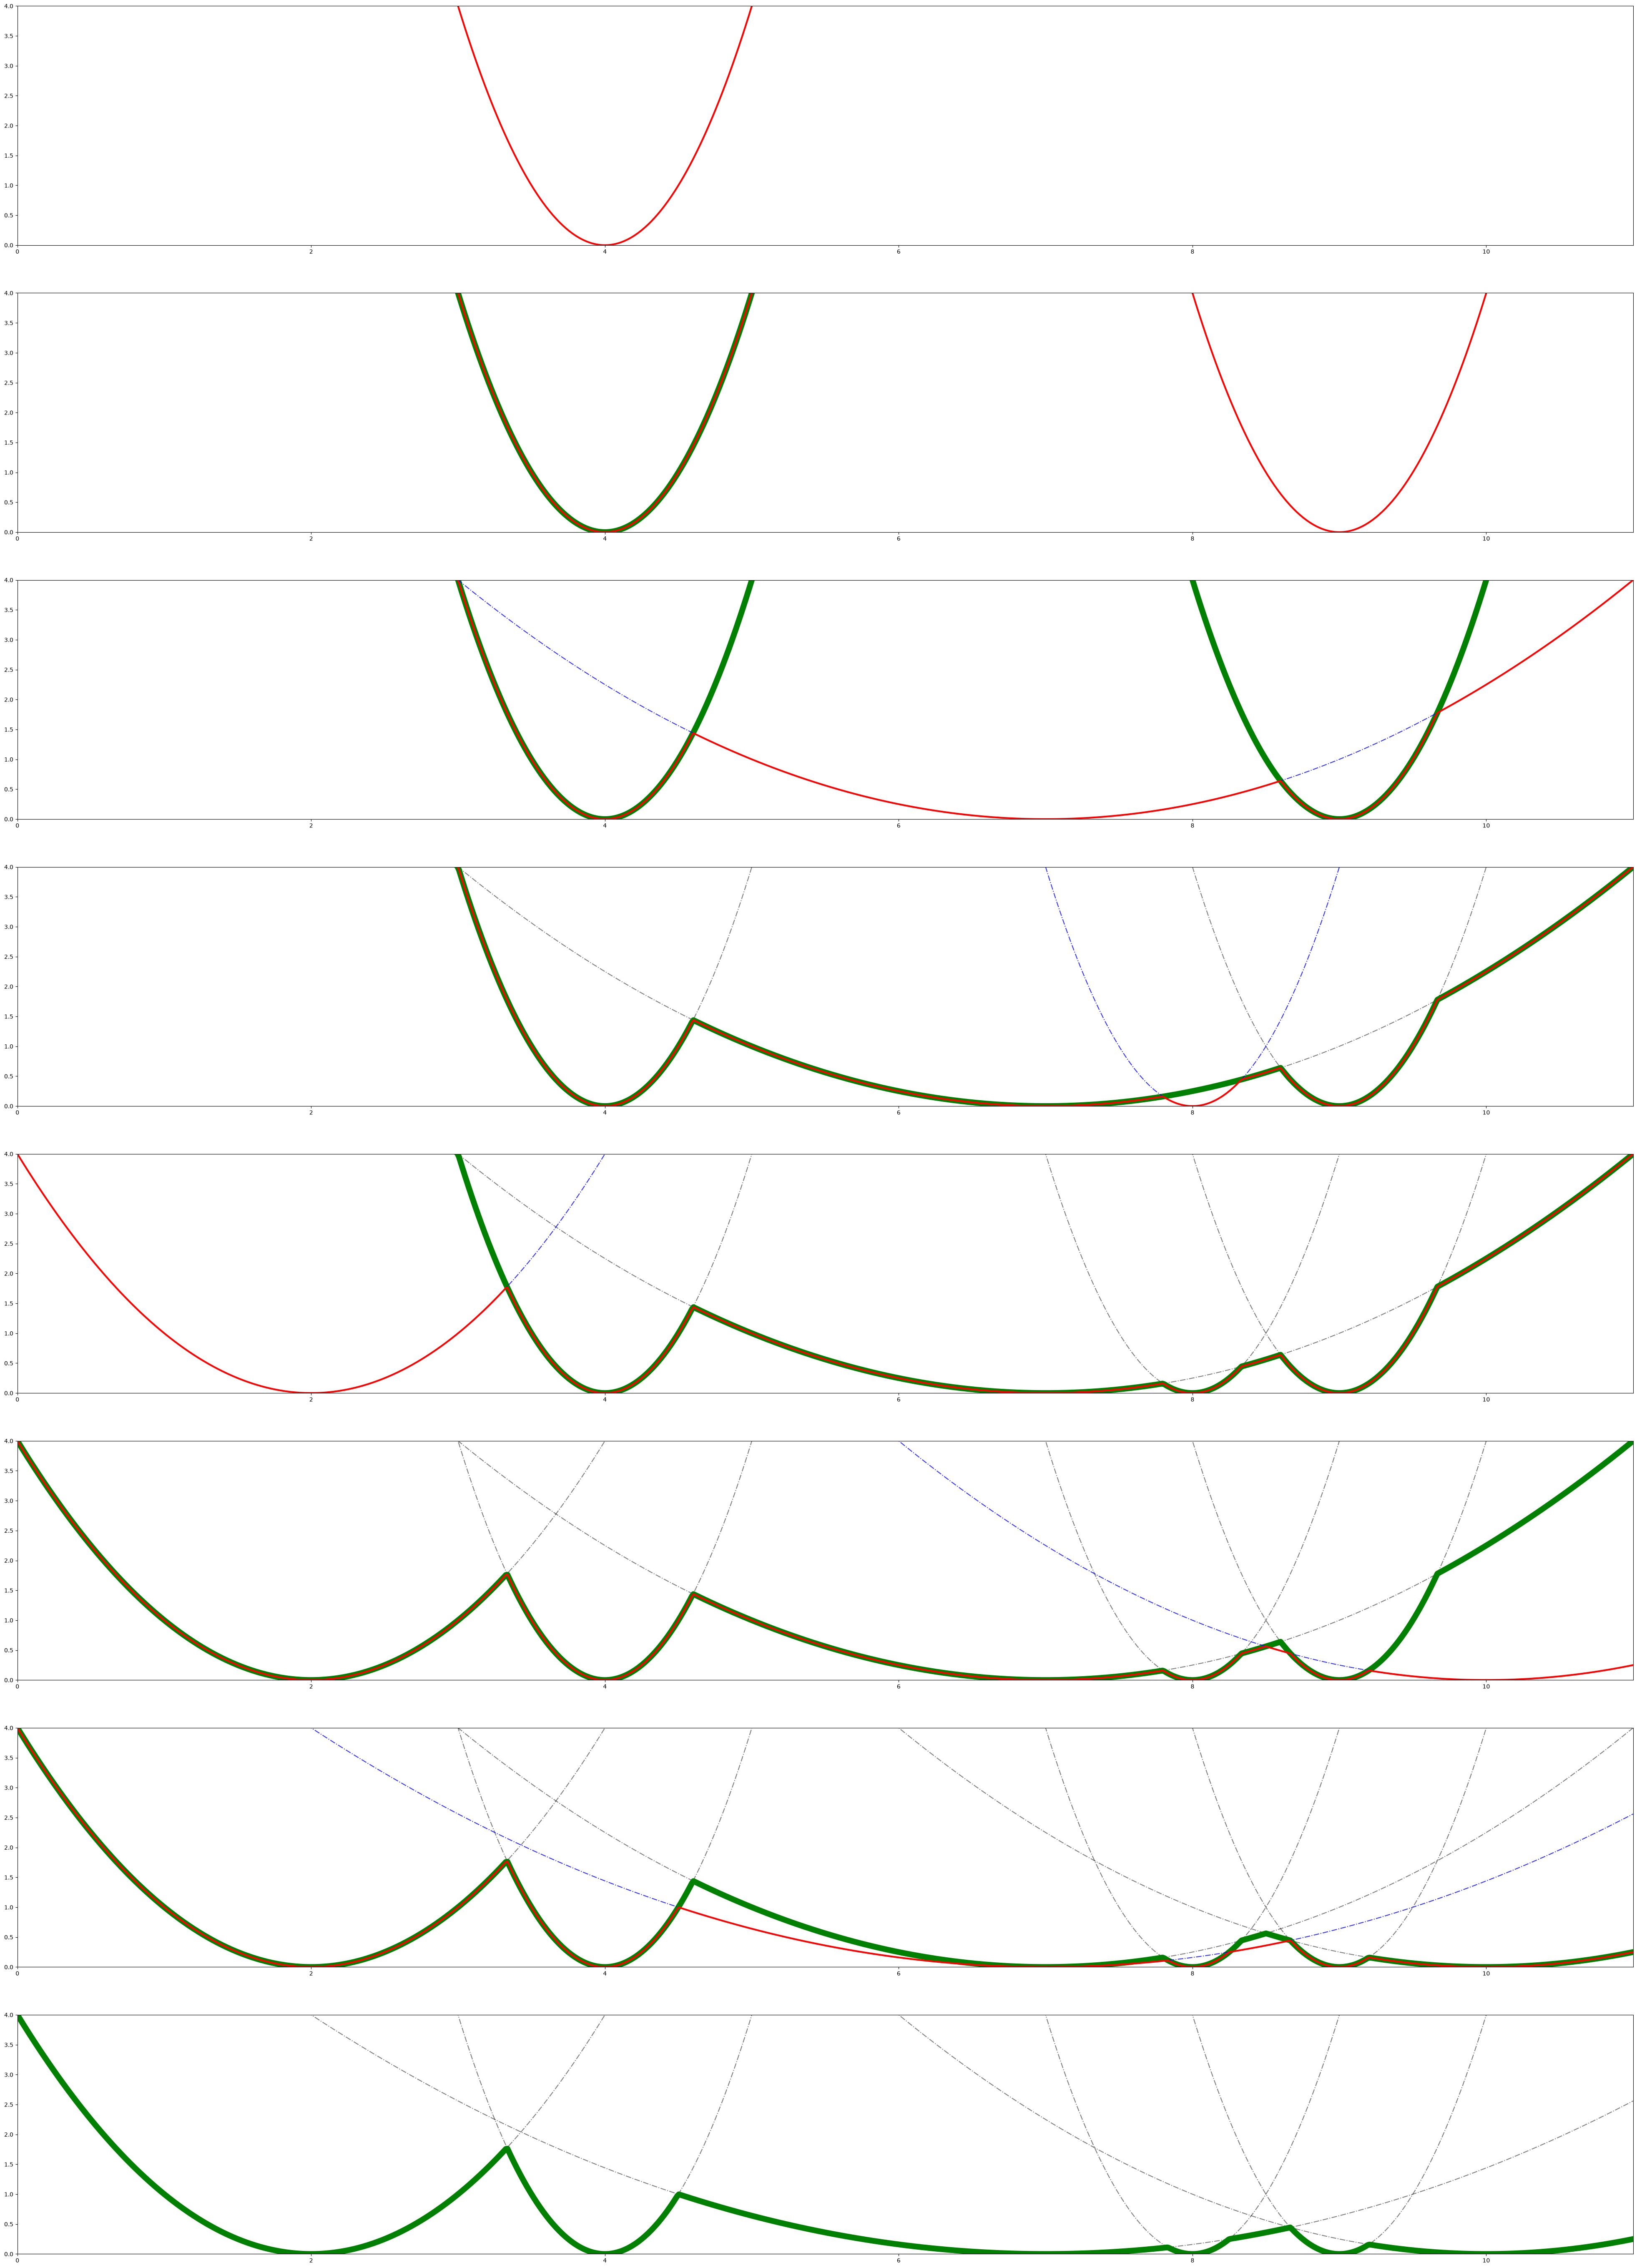

In [372]:
my_range = (0, 11)
power = lambda e: lambda x: x**e
f = power(2)
data = [(2, 4), (2, 9), (.5, 7), (2, 8), (1, 2), (.5, 10), (.4, 7)]

hull = show_iterative_fig(f, my_range, data)

defined by :
((2, 4), [S[3.3333333333333335, 4.500000000000001]S])
((2, 9), [S[8.666666666666668, 9.2]S])
((2, 8), [S[7.833333333333334, 8.249999999999998]S])
((1, 2), [S[0, 3.3333333333333335]S])
((0.5, 10), [S[9.2, 11]S])
((0.4, 7), [S[4.500000000000001, 7.833333333333334]S, S[8.249999999999998, 8.666666666666668]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.500000000000001]S])
((2, 9), [S[8.666666666666668, 9.2]S])
((2, 8), [S[7.833333333333334, 8.249999999999998]S])
((1, 2), [S[0.6666666666666666, 3.3333333333333335]S])
((0.5, 10), [S[9.2, 11]S])
((0.4, 7), [S[4.500000000000001, 7.833333333333334]S, S[8.249999999999998, 8.666666666666668]S])
((2, 0.0), [S[0, 0.6666666666666666]S])
on : S[0, 11]S
defined by :
((2, 4), [S[3.3333333333333335, 4.500000000000001]S])
((2, 9), [S[8.666666666666668, 9.2]S])
((2, 8), [S[7.833333333333334, 8.249999999999998]S])
((1, 2), [S[0, 3.3333333333333335]S])
((0.5, 10), [S[9.2, 11]S])
((0.4, 7), [S[4.500000000000001, 7.833333333333

Exception: the function should be defined on the total range it takes values in

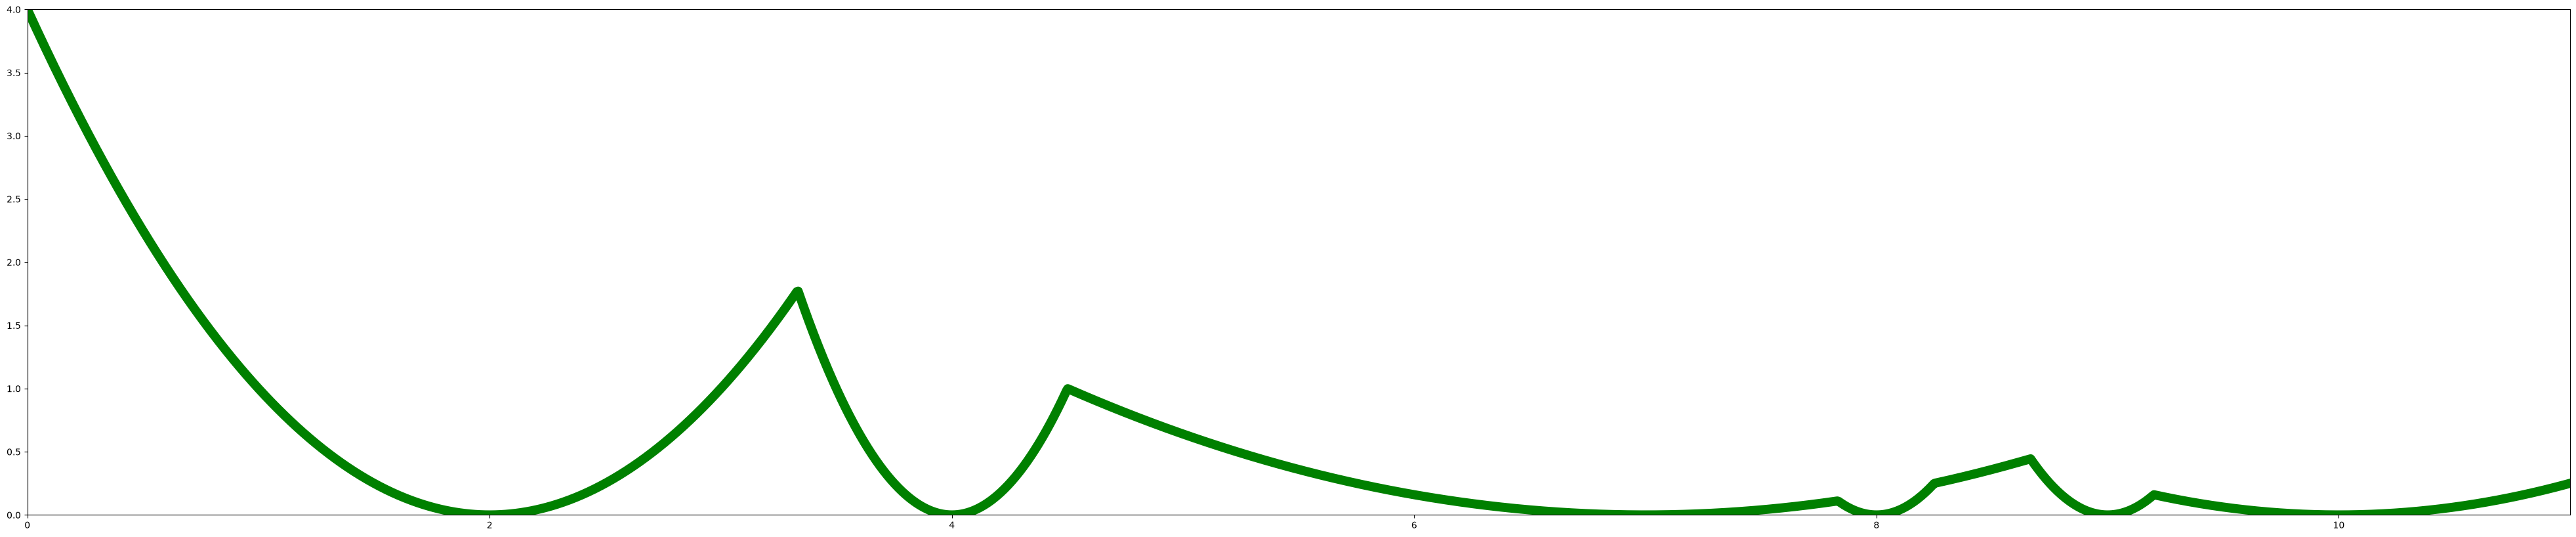

In [381]:
hull.set_primitive(lambda a: (lambda x: a**2 * x**3/3.))

nb_points_hull, nb_points_score = 2000, 200
x_hull = np.linspace(*hull.get_range().as_tuple(), nb_points_hull)
x_score = np.linspace(*hull.get_range().as_tuple(), nb_points_score)

fig, ax = plt.subplots(1, 1, figsize=(50, 10))
plot_draw(ax, x_hull, hull, False)

test = [hull.score_of_new_curb_test((2, float(x))) for x in x_score]
ax.plot(x_score, test)


/tmp/ipykernel_23429/3108490234.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


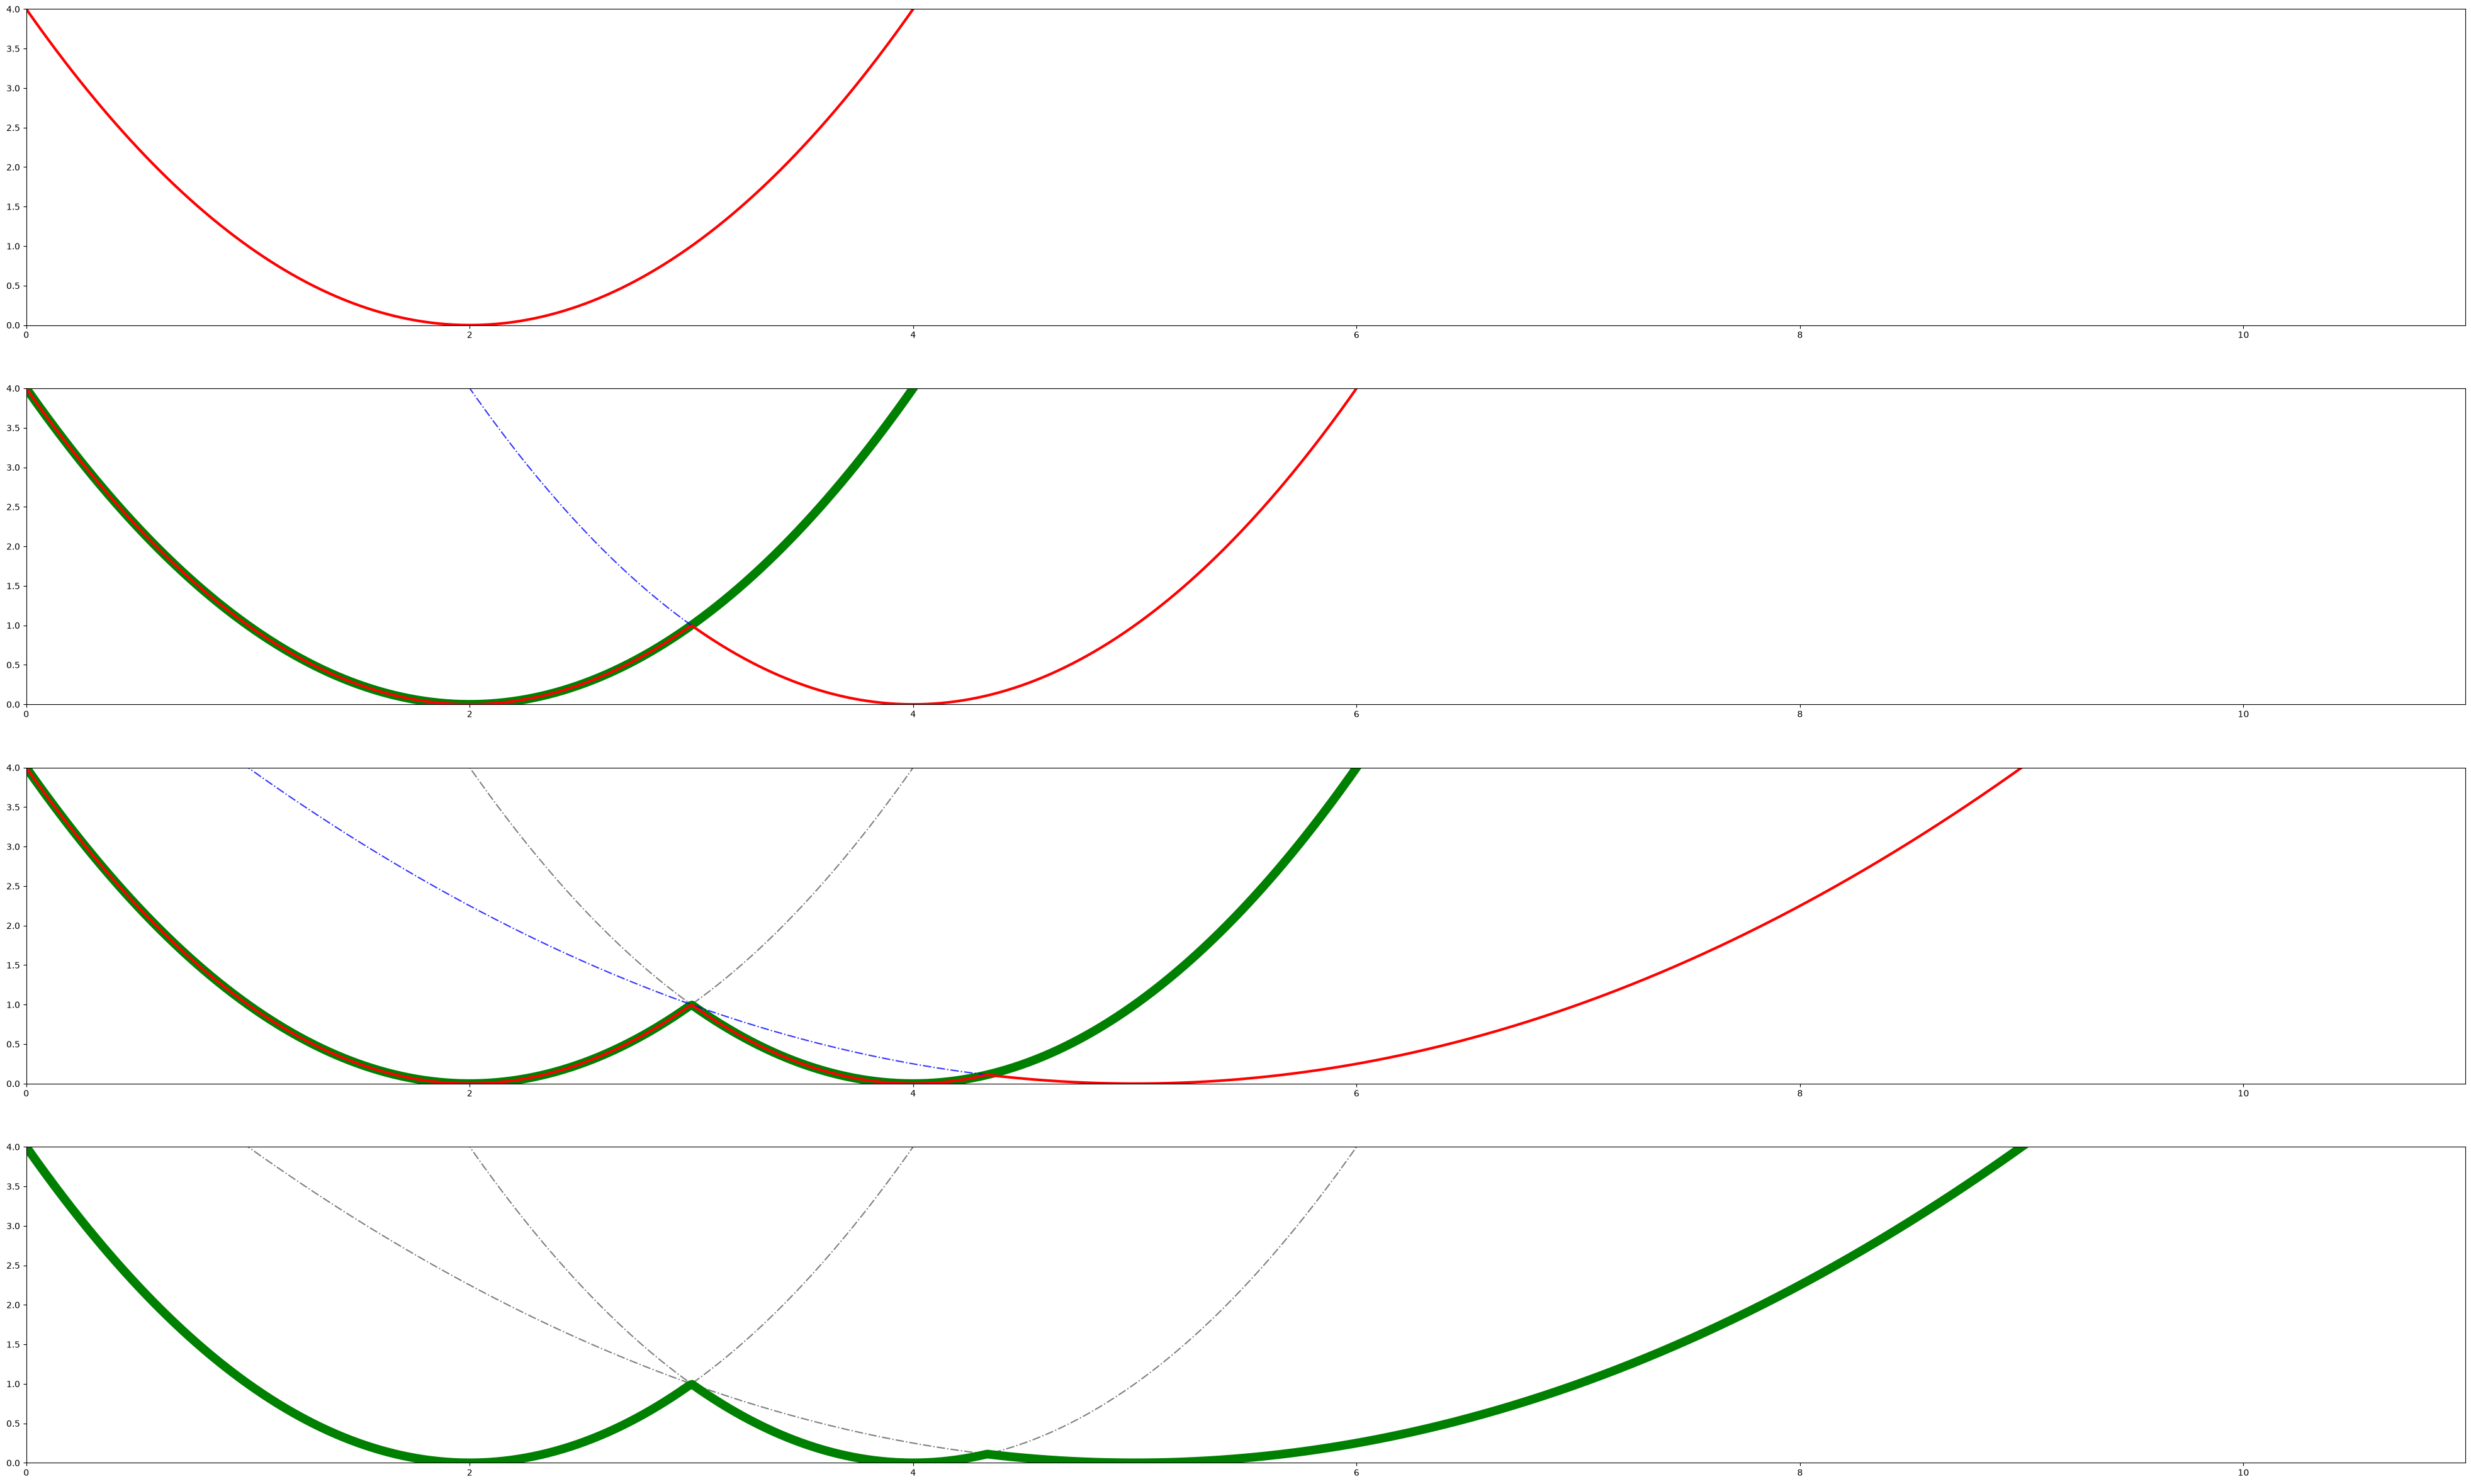

In [259]:
data = [(1, 2), (1, 4), (.5, 5)]

show_iterative_fig(f, my_range, data)